# 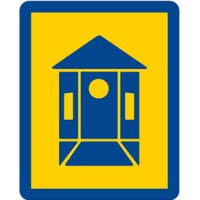

**Actividad / Parcial (Segundo Cohorte)**<br>
**Electiva II - Introducción a Ciencia de Datos (Extracción de datos mediante webscraping)**<br>

**Institución Universitaria Colegio Mayor del Cauca**<br>
**2026 - I**<br>

# Tarea 1: Extracción de datos mediante webscrapping.

***
## Instrucciones Generales:
- Esta actividad debe ser desarrollada utilizando el lenguaje de programación Python, en este mismo Notebook.
- El Notebook debe estar  ordenado, seguir buenas prácticas de escritura y programación, se vale agregar comentarios cuando se requiera o un texto descriptivo si lo consideran necesario.
- La actividad deberá ser sustentada por todos los miembros del grupo/equipo.
- El Notebook ya contiene algunas celdas marcadas con el comentario `#código de inicio`. Estas celdas han sido incluidas como ayuda para el desarrollo de la actividad, y pueden ser ejecutadas tal como están.
- Las celdas marcadas como `#completar código` tienen un código parcial que debe ser completado para poder ser ejecutado. Ud debe agregar todas las líneas o bloques de código necesarios para desarrollar correctamente cada punto de la tarea. También puede eliminar estas celdas y partir el código desde cero si le resulta más conveniente.

## 📊 Introducción

En los últimos años, la **ciencia de datos** se ha consolidado como una de las disciplinas más demandadas en el ámbito tecnológico y empresarial. Según el informe "*The Future of Jobs Report 2023*" del **Foro Económico Mundial**, los roles relacionados con análisis de datos y aprendizaje automático figuran entre los más prometedores en cuanto a crecimiento y transformación del mercado laboral global.

🔗 [The Future of Jobs Report 2025 – World Economic Forum](https://www.weforum.org/publications/the-future-of-jobs-report-2025/)

Este auge responde a la creciente necesidad de las organizaciones de interpretar grandes volúmenes de datos para tomar decisiones informadas, optimizar procesos y generar ventajas competitivas. Como consecuencia, las vacantes para perfiles como *científicos de datos*, *analistas de datos* y *especialistas en inteligencia artificial* han aumentado significativamente, especialmente en sectores como tecnología, salud, finanzas y comercio.

Aunque muchas de las estadísticas y proyecciones provienen de estudios realizados en Norteamérica y Europa, **América Latina** también está experimentando una expansión en este campo. Diversas consultoras y portales como *Michael Page* destacan el crecimiento sostenido de la demanda por talento en datos en países como Colombia, México, Brasil y Chile.

En este contexto, usted ha sido asignado al diseño de un estudio que explore el estado actual del mercado laboral para científicos de datos en América Latina. Como primer paso, se requiere construir una base de datos con vacantes extraídas directamente de portales abiertos de empleo, como **LinkedIn Jobs**, mediante técnicas de *web scraping*.

🔗 [Portal de empleos: LinkedIn Jobs](https://www.linkedin.com/jobs/)

>*Este ejercicio fue inspirado por diversos recursos didácticos disponibles en línea y adaptado con fines académicos.*





In [15]:
#Impoactamos las librerias necesarias
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time


**1.** Ingrese a la página web de www.linkedin.com/jobs y realice una búsqueda de empleos para el **cargo/posición: 'data scientist'**, **país/ubicación: 'EEUU'**. Utilice la url generada en el punto 2 (Ver Punto 2) y abra esta dirección en modo incognito para evitar inconvenientes o posibles bloqueos desde el servidor de Linkedin al intentar generar peticiones al servidor.

Inspeccione y analice el código fuente de la página de resultados, para entender la estructura de su código HTML.

En base a su inspección del código HTML, responda: ¿Qué elemento del código le permite llegar exactamente a la lista de anuncios de empleo?

---
#### Inspeccion del codigo HTML de LinkedIn Jobs

Se accedio a [LinkedIn Jobs](https://www.linkedin.com/jobs/search/?keywords=data+scientist&location=United+States) en modo incognito realizando una busqueda de **'data scientist'** en **'United States (EEUU)'**.

Al inspeccionar el codigo fuente de la pagina de resultados, se identifico que cada anuncio de empleo esta contenido en un elemento `<li>` dentro de una lista `<ul>`. Cada tarjeta es un `<div class="base-card">` con los siguientes sub-elementos:

| Campo | Selector |
|---|---|
| Titulo | `h3.base-search-card__title` |
| Empresa | `h4.base-search-card__subtitle` |
| Localizacion | `span.job-search-card__location` |
| URL | `a.base-card__full-link` atributo `href` |

**El elemento que permite llegar exactamente a la lista de anuncios es:**
```html
<ul class="jobs-search__results-list">
```
Cada `<li>` dentro de esta lista corresponde a un anuncio de empleo individual.


---
####  Inspeccion del codigo HTML de LinkedIn Jobs

Se accedio a [LinkedIn Jobs](https://www.linkedin.com/jobs/search/?keywords=data+scientist&location=United+States) en modo incognito realizando una busqueda de **'data scientist'** en **'United States (EEUU)'**.

Al inspeccionar el codigo fuente de la pagina de resultados, se identifico que cada anuncio de empleo esta contenido en un elemento `<li>` dentro de una lista `<ul>`. Cada tarjeta es un `<div class="base-card">` con los siguientes sub-elementos:

| Campo | Selector |
|---|---|
| Titulo | `h3.base-search-card__title` |
| Empresa | `h4.base-search-card__subtitle` |
| Localizacion | `span.job-search-card__location` |
| URL | `a.base-card__full-link` atributo `href` |

**El elemento que permite llegar exactamente a la lista de anuncios es:**
```html
<ul class="jobs-search__results-list">
```
Cada `<li>` dentro de esta lista corresponde a un anuncio de empleo individual.


---
#### 2. Extraiga la lista de anuncios de trabajo arrojados por su búsqueda en Linkedin.

In [16]:
# Esto sirve para que la petición HTTP parezca hecha por un navegador real.
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'Accept-Language': 'en-US,en;q=0.9',
}

todos_empleos = []
# Bucle de paginación
for start in range(0, 500, 10):
    url = (
        "https://www.linkedin.com/jobs-guest/jobs/api/seeMoreJobPostings/search"
        f"?keywords=data+scientist"
        f"&location=United+States"
        f"&f_E=1"        # Sin experiencia (Entry level)
        f"&f_TPR=r86400" # Últimas 24 horas
        f"&start={start}"
    )
    # Hace la solicitud a LinkedIn
    respuesta = requests.get(url, headers=headers, timeout=20)
    # Convierte el HTML en un objeto manipulable
    # Busca todos los <li> (cada empleo está dentro de uno)
    soup = BeautifulSoup(respuesta.text, "html.parser")
    lista = soup.find_all("li")
    # Si ya no hay resultados:  se detiene el bucle
    if len(lista) == 0:
        print(f"Sin más resultados en start={start}")
        break
    # Agrega los empleos encontrados a la lista principal
    todos_empleos.extend(lista)
    print(f"start={start} → {len(lista)} empleos | Total: {len(todos_empleos)}")
    # Pausa (anti-bloqueo)
    time.sleep(2)

print(f"\nTotal extraídos: {len(todos_empleos)}")

start=0 → 10 empleos | Total: 10
start=10 → 10 empleos | Total: 20
start=20 → 10 empleos | Total: 30
start=30 → 2 empleos | Total: 32
Sin más resultados en start=40

Total extraídos: 32


#### 3. Seleccione por ahora sólo el primer anuncio de la lista, y extraiga la información de:  título del trabajo, nombre de la compañía, localización, y URL del anuncio.

Nota: Por localización se entiende la ciudad, comuna o municipio indicado en el anuncio.

In [17]:
head = {
    'User-Agent': 'Mozilla/5.0',
    'Accept-Language': 'en-US,en;q=0.9',
}

url = "https://www.linkedin.com/jobs-guest/jobs/api/seeMoreJobPostings/search?keywords=data+scientist&location=United+States&start=0"

respuesta = requests.get(url, headers=head, timeout=20)
print("Código HTTP:", respuesta.status_code)

soup = BeautifulSoup(respuesta.text, "html.parser")
lista_empleos = soup.find_all("li")

# Validar que haya resultados
if not lista_empleos:
    print("No se encontraron empleos")
else:
    primer_anuncio = lista_empleos[0]

    titulo_tag = primer_anuncio.find("h3", class_="base-search-card__title")
    empresa_tag = primer_anuncio.find("h4", class_="base-search-card__subtitle")
    loc_tag = primer_anuncio.find("span", class_="job-search-card__location")
    link_tag = primer_anuncio.find("a", class_="base-card__full-link")

    print("=== Primer anuncio extraído ===")
    print("Titulo      :", titulo_tag.get_text(strip=True) if titulo_tag else "No disponible")
    print("Empresa     :", empresa_tag.get_text(strip=True) if empresa_tag else "No disponible")
    print("Localización:", loc_tag.get_text(strip=True) if loc_tag else "No disponible")
    print("URL         :", link_tag.get("href") if link_tag else "No disponible")

Código HTTP: 200
=== Primer anuncio extraído ===
Titulo      : Data Scientist
Empresa     : Tinder
Localización: Los Angeles, CA
URL         : https://www.linkedin.com/jobs/view/data-scientist-at-tinder-4407688060?position=1&pageNum=0&refId=PQWv7ZlhNImxM7hunnLs0Q%3D%3D&trackingId=GFNmNplBBGkc2KCjM%2B58ew%3D%3D


#### 4. En base a los puntos anteriores, programe una rutina para extraer la información de localización,  título del trabajo, nombre de la compañía, localización, y URL del anuncio para todos los trabajos arrojados por su búsqueda de Linkedin, y almacenar los datos en un dataframe de pandas.

In [21]:
# Lista para almacenar los datos
empleos = []

# Recorrer todos los trabajos
for job in todos_empleos:
    titulo_tag = job.find("h3", class_="base-search-card__title")
    empresa_tag = job.find("h4", class_="base-search-card__subtitle")
    loc_tag = job.find("span", class_="job-search-card__location")
    link_tag = job.find("a", class_="base-card__full-link")

    empleos.append({
        "titulo": titulo_tag.get_text(strip=True) if titulo_tag else None,
        "empresa": empresa_tag.get_text(strip=True) if empresa_tag else None,
        "localizacion": loc_tag.get_text(strip=True) if loc_tag else None,
        "url": link_tag.get("href") if link_tag else None
    })

# Crear DataFrame
df = pd.DataFrame(empleos)

# Ver resultado
df.head()

,titulo,empresa,localizacion,url
0,Data Scientist - Internship [Summer 2026],Two Sigma,"New York, United States",https://www.linkedin.com/jobs/view/data-scient...
1,AI & ML Engineering Intern,Zello,"Austin, TX",https://www.linkedin.com/jobs/view/ai-ml-engin...
2,Machine Learning Engineer Graduate (Data-Searc...,TikTok,"San Jose, CA",https://www.linkedin.com/jobs/view/machine-lea...
3,Product Data Science Intern,Docusign,"Seattle, WA",https://www.linkedin.com/jobs/view/product-dat...
4,Intern Data Scientist,SES Satellites,"Chicago, IL",https://www.linkedin.com/jobs/view/intern-data...


#### 5. Exporte su dataframe a un archivo en formato .csv, .xls o el que usted considere conveniente de tal forma que lo pueda visualizar en su equipo de forma local sin ningún inconveniente.

In [22]:
# Exportamos a CSV con codificacion UTF-8 (compatible con Excel)
df.to_csv("empleos_data_scientist_eeuu.csv", index=False, encoding="utf-8-sig")

print("Archivo exportado: empleos_data_scientist_eeuu.csv")
print(f"Registros guardados: {len(df)}")


Archivo exportado: empleos_data_scientist_eeuu.csv
Registros guardados: 32


#### 6. ¿Cuántas ofertas de empleo contiene su dataframe, y cuántos resultados hay en total en la búsqueda de Linkedin? Comente sobre las diferencias o coincidencias, y explique qué debería hacer para extraer todos los resultados disponibles en Linkedin.


In [23]:
# Punto 6 - Análisis de resultados

total_linkedin = 404   # número que muestra LinkedIn en la página con los filtros aplicados
total_dataframe = len(df)  # 32

print(f"Resultados totales en LinkedIn : {total_linkedin}")
print(f"Registros en el DataFrame      : {total_dataframe}")
print(f"Diferencia                     : {total_linkedin - total_dataframe}")

Resultados totales en LinkedIn : 404
Registros en el DataFrame      : 32
Diferencia                     : 372


#### Análisis de resultados

**¿Cuántas ofertas contiene el DataFrame?** 32 registros.

**¿Cuántos resultados hay en LinkedIn?** 404 empleos (con filtros: 
Data Scientist, Estados Unidos, Sin experiencia, Últimas 24 horas).

**Diferencia:** Se extrajeron 32 de 404 .  
Esto ocurre porque LinkedIn limita a **10 resultados por petición** 
y el scraper iteró sobre páginas hasta que LinkedIn dejó de devolver 
resultados, posiblemente bloqueando después de cierto número de peticiones.

**¿Cómo extraer todos los resultados?**  
Se debe continuar incrementando el parámetro `start` de 10 en 10 
hasta cubrir los 404 resultados (~40 páginas). Sin embargo, LinkedIn 
puede bloquear la IP tras múltiples peticiones seguidas. Para evitarlo:

1. Aumentar el `time.sleep()` entre peticiones (ej. 5 segundos)
2. Rotar el `User-Agent` en cada petición
3. Usar proxies para distribuir las peticiones
4. Considerar el uso de la API oficial o métodos autenticados